In [1]:
import sys
from pyprojroot import here

# Ritorna il percorso assoluto della root del progetto
PROJECT_ROOT = str(here()) + "/"
sys.path.append(PROJECT_ROOT)

print(f"La root del progetto è: {PROJECT_ROOT}")

La root del progetto è: /home/cvalentino/SissaUnisaDraftCodes/


In [2]:
from paths import INV_PATH, TP1_PATH

ABS_PATH = PROJECT_ROOT + INV_PATH + TP1_PATH
LOAD_MSH = PROJECT_ROOT

model_name = "rock"
xdmf_file_name = "rock.xdmf"

# Nome figure
fig_dir = "figures/"
eig_fig = ABS_PATH + fig_dir + "sv.png"
error_fig = ABS_PATH + fig_dir + "error.png"
speed_up_fig = ABS_PATH + fig_dir + "speed_up.png"
samples_fig = ABS_PATH + fig_dir + "samples.png"

dbdir = ABS_PATH + "database/"

In [4]:
import fenics as fe

from fem_problems.invTP1.finite_element import PoissonFEM
from fem_problems.invTP1.rbnics_pod import PODReduction

[michael-Alienware-Aurora-R15:872815] shmem: mmap: an error occurred while determining whether or not /tmp/ompi.michael-Alienware-Aurora-R15.1001/jf.0/558235648/shared_mem_cuda_pool.michael-Alienware-Aurora-R15 could be created.
[michael-Alienware-Aurora-R15:872815] create_and_attach: unable to create shared memory BTL coordinating structure :: size 134217728 


Carichiamo la mesh

In [5]:
# Path to the XDMF file
file_path = ABS_PATH + xdmf_file_name

# Carica la mesh da file XDMF
mesh = fe.Mesh()
with fe.XDMFFile(file_path) as infile:
    infile.read(mesh)

Definiamo il range dei parametri

In [6]:
mu_range = [
    (0, 1.),
    (0, 1.),
    (0, 1.),
]

Definiamo il problema fem e il pod

In [7]:
fem_p = PoissonFEM(mesh)
pod = PODReduction(mu_range, fem_p)

In [8]:
num_training = 100
num_testing = 10

N_modes = num_training
tol = 1e-9

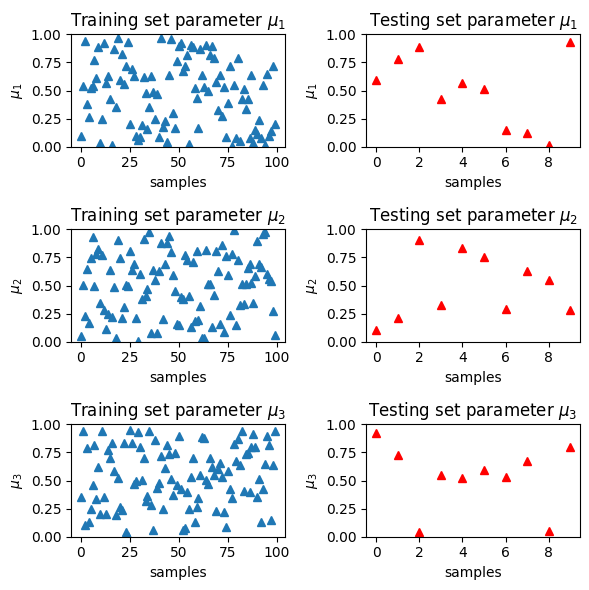

In [9]:
training = pod.sampling_parameters(num_training)
testing = pod.sampling_parameters(num_testing, test=True)
pod.plot_samples(figsize = (6, 6), filename=samples_fig)

In [10]:
pod.pod_execution(N_modes, tol)

STORING SNAPSHOTS...
+++ Compute and store snaphot 1 for mu = [0.09737673 0.05162534 0.35205003] +++
+++ Compute and store snaphot 2 for mu = [0.54323442 0.50540653 0.93823953] +++
+++ Compute and store snaphot 3 for mu = [0.94078368 0.2295917  0.1055023 ] +++
+++ Compute and store snaphot 4 for mu = [0.38302065 0.64795162 0.78557274] +++
+++ Compute and store snaphot 5 for mu = [0.26041349 0.16241979 0.12877932] +++
+++ Compute and store snaphot 6 for mu = [0.51973873 0.74511779 0.24281403] +++
+++ Compute and store snaphot 7 for mu = [0.5387703  0.93522389 0.46264069] +++
+++ Compute and store snaphot 8 for mu = [0.77348171 0.49387976 0.81288696] +++
+++ Compute and store snaphot 9 for mu = [0.60911037 0.78481321 0.33811748] +++
+++ Compute and store snaphot 10 for mu = [0.88538042 0.82494201 0.62294629] +++
+++ Compute and store snaphot 11 for mu = [0.0316756  0.34843035 0.20123129] +++
+++ Compute and store snaphot 12 for mu = [0.24672411 0.77052337 0.94414167] +++
+++ Compute and 

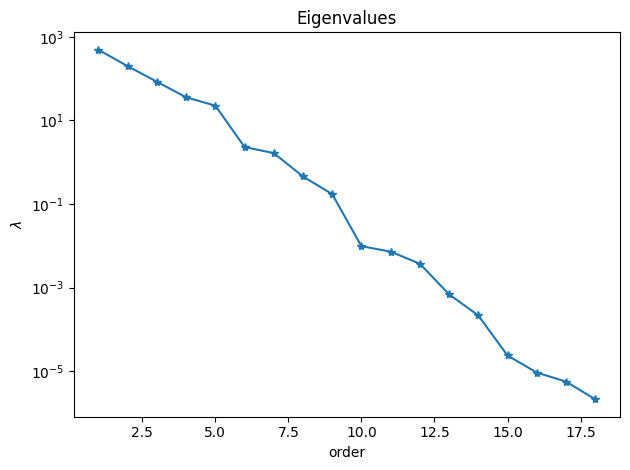

In [ ]:
pod.plot_eigenvalues(filename=eig_fig)

In [12]:
pod.store_reduction(directory=dbdir, filename=model_name)

Start STORING REDUCTION......End STORING REDUCTION


In [13]:
mu_test = [.2, .6, .4]
mat, _ = pod.solve_rom(mu_test, pod.num_basis)
fom_m, _ = pod.fem_p.solve_fem(mu_test)
real_m, _ = pod.fem_p.exact_solution(mu_test)

print("ERRORE FOM-ESATTA")
e, f = pod.fem_p.compute_error(fom_m, real_m)
print("ERRORE ROM-FOM")
a, b = pod.fem_p.compute_error(mat, fom_m)
print("ERRORE ROM-ESATTA")
c, d = pod.fem_p.compute_error(mat, real_m)

ERRORE FOM-ESATTA
Errore Assoluto: 1.7453e+00
Errore Relativo: 1.2078e-01
ERRORE ROM-FOM
Errore Assoluto: 3.6246e-04
Errore Relativo: 2.6819e-05
ERRORE ROM-ESATTA
Errore Assoluto: 1.7453e+00
Errore Relativo: 1.2077e-01


In [14]:
error, _ = pod.error_analysis()


=============== POD basis number N = 1 ===============
Solve for test parameter i = 0, mu=[0.58924573 0.10709244 0.92074234]
Solve for test parameter i = 1, mu=[0.77814575 0.21376485 0.72612358]
Solve for test parameter i = 2, mu=[0.8873395  0.90634139 0.04283294]
Solve for test parameter i = 3, mu=[0.42596385 0.32304844 0.54946776]
Solve for test parameter i = 4, mu=[0.56637895 0.83380301 0.51920871]
Solve for test parameter i = 5, mu=[0.5173553  0.75153539 0.5903105 ]
Solve for test parameter i = 6, mu=[0.14984792 0.28705709 0.53022801]
Solve for test parameter i = 7, mu=[0.12132741 0.62945952 0.67169047]
Solve for test parameter i = 8, mu=[0.0137407  0.55199093 0.05256497]
Solve for test parameter i = 9, mu=[0.93508132 0.28586018 0.79435553]

=============== POD basis number N = 2 ===============
Solve for test parameter i = 0, mu=[0.58924573 0.10709244 0.92074234]
Solve for test parameter i = 1, mu=[0.77814575 0.21376485 0.72612358]
Solve for test parameter i = 2, mu=[0.8873395  0

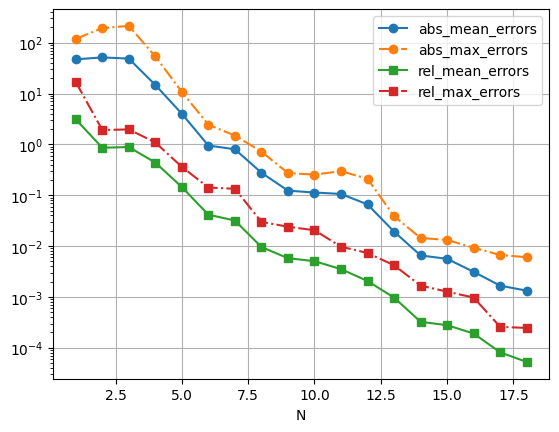

In [15]:
pod.plot_errors(error, filename=error_fig)

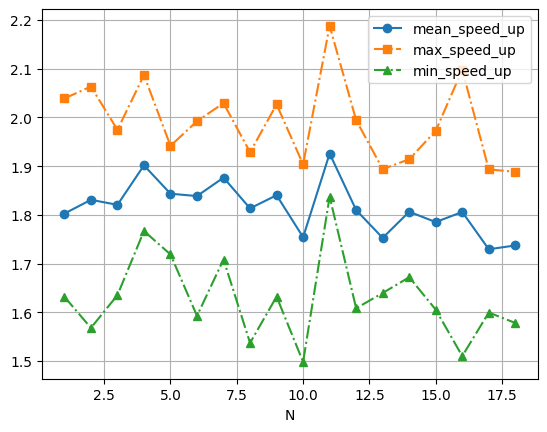

In [16]:
pod.plot_speed_up(error, filename=speed_up_fig)

In [17]:
pod.save_table_error(error)

In [18]:
pod.table_error(error)

Solution errors:
+-----+-----------------+----------------+--------------------------+-------------------------+------------+
|   N |   mean(error_u) |   max(error_u) |   mean(relative_error_u) |   max(relative_error_u) |   speed_up |
+=====+=================+================+==========================+=========================+============+
|   1 |     47.0799     |   118.657      |              3.10885     |            16.9324      |    1.8027  |
+-----+-----------------+----------------+--------------------------+-------------------------+------------+
|   2 |     51.3401     |   193.82       |              0.859395    |             1.91227     |    1.83102 |
+-----+-----------------+----------------+--------------------------+-------------------------+------------+
|   3 |     48.6677     |   213.689      |              0.885795    |             1.97169     |    1.82072 |
+-----+-----------------+----------------+--------------------------+-------------------------+------------+
| 